In [4]:
!pip install prophet
print("success")

success


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
print("success")

success


In [14]:
# read the csv file
df = pd.read_csv("Sample_Superstore.csv",encoding = "latin1")
print("Raw data loaded:",df.shape)

Raw data loaded: (9994, 21)


In [15]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [16]:
# replace column with lowercase
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_",regex=False)
df = df.rename(columns = {'sub-category':'sub_category'})
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [17]:
# clean the data
df["order_date"] = pd.to_datetime(df["order_date"],format="%m/%d/%Y")
df["ship_date"] = pd.to_datetime(df["ship_date"],format="%m/%d/%Y")
df["postal_code"] = df["postal_code"].astype(str)

In [18]:
# create column new
df["days_to_ship"] = (df["ship_date"] - df["order_date"]).dt.days
df["profit_margin"] = (df["profit"] / df["sales"]).round(4)
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month_name()
df["quarter"] = df["order_date"].dt.quarter
print("cleaning done added columns")

cleaning done added columns


In [19]:
!pip install prophet

In [20]:
import matplotlib.pyplot as plt
from prophet import Prophet
print("success")

success


In [25]:
monthly_sales = (
    sales
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)
print("success")

success


In [26]:
monthly_sales.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [27]:
monthly_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  48 non-null     datetime64[ns]
 1   Sales       48 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 900.0 bytes


In [28]:
monthly_sales = monthly_sales.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

In [29]:
monthly_sales.head()

,ds,y
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [31]:
# create
model = Prophet()
model.fit(monthly_sales)
print("success")

18:08:28 - cmdstanpy - INFO - Chain [1] start processing
18:08:29 - cmdstanpy - INFO - Chain [1] done processing


success


In [32]:
# create future date
future = model.make_future_dataframe(periods=12,freq="ME")


In [33]:
future.tail()

,ds
55,2018-08-31
56,2018-09-30
57,2018-10-31
58,2018-11-30
59,2018-12-31


In [34]:
forecast = model.predict(future)
print("success")

success


In [35]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
55,2018-08-31,61936.115362,52614.104275,71488.532166
56,2018-09-30,98895.785086,88340.615654,107228.157095
57,2018-10-31,67553.702926,57577.924662,76641.044537
58,2018-11-30,109972.726998,100328.078083,119244.912465
59,2018-12-31,101864.690255,93201.628354,111941.564030


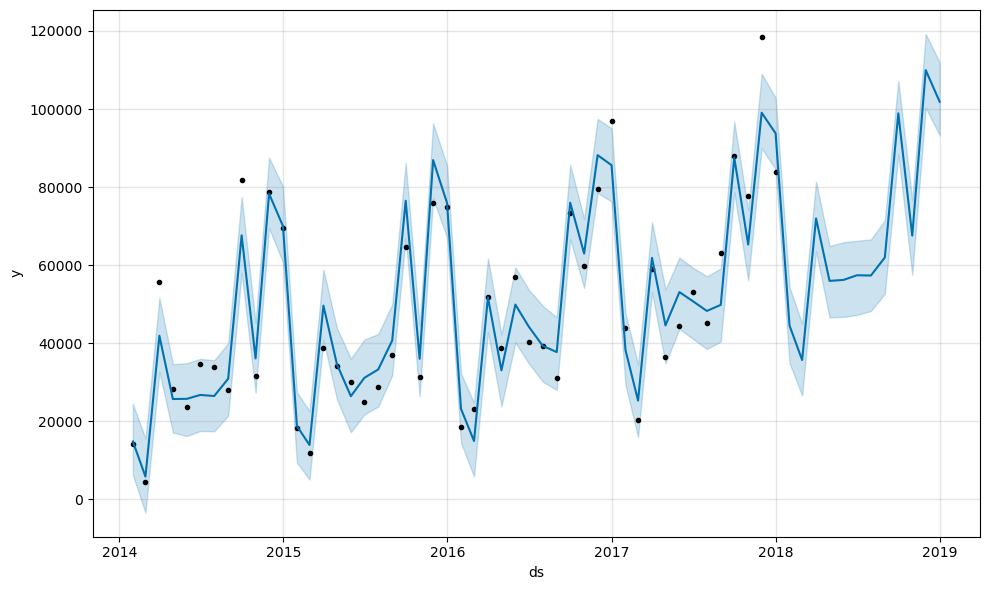

In [36]:
# plot the forecast
fig = model.plot(forecast)

In [38]:
plt.show()

fig2 = model.plot_components(forecast)
print("success")

## Forecast Observations

1. The Prophet model identified an overall upward trend in monthly sales.

2. The model detected yearly seasonality, indicating that sales vary across different months of the year.

3. The forecast predicts monthly sales for the next 12 months based on historical trends and seasonal patterns.

4. The prediction interval indicates the possible range of future sales, reflecting uncertainty in the forecast.

## Business Recommendations

1. Increase inventory before high-demand periods to avoid stock shortages.

2. Plan marketing campaigns during low-sales months to improve revenue.

3. Use sales forecasts to support budgeting, inventory planning, and staffing decisions.

4. Continuously monitor actual sales against forecasted sales and update the forecasting model with new data.

## Conclusion

This project successfully analyzed retail sales data using Python, SQL, PostgreSQL, Power BI, and Prophet forecasting. Historical sales data was cleaned, transformed, and analyzed to identify business trends and customer purchasing patterns. Interactive dashboards were developed in Power BI to visualize key performance indicators and sales performance. Finally, the Prophet forecasting model was used to predict monthly sales for the next 12 months, providing valuable insights for inventory planning, budgeting, and business decision-making. The project demonstrates how data analytics and forecasting techniques can support strategic business decisions.